In [3]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [4]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [5]:
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [6]:
model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 132ms/step - accuracy: 0.7814 - loss: 0.4601 - val_accuracy: 0.8022 - val_loss: 0.4314
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 133ms/step - accuracy: 0.8899 - loss: 0.2761 - val_accuracy: 0.8446 - val_loss: 0.3524
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 183ms/step - accuracy: 0.9266 - loss: 0.1920 - val_accuracy: 0.8758 - val_loss: 0.3226
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.8664 - loss: 0.3342
Accuracy: 0.8663600087165833


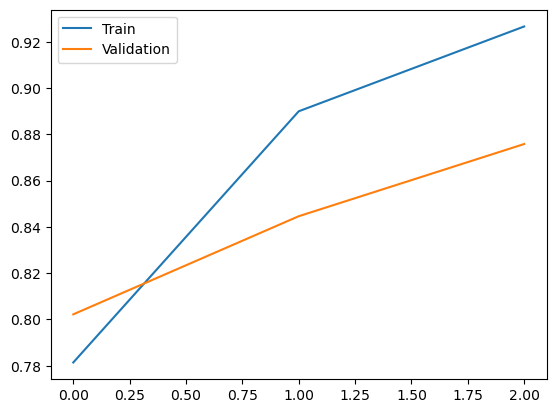

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.show()